In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(4)
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 12

In [27]:
def generate_data(n=20, a_true=2, b_true=2, seed=4):
    x = np.linspace(-1.8, 2.0, n)
    np.random.seed(seed)
    eps = np.random.normal(0, 1, n)
    y = a_true + b_true * x + eps
    return x, y

def add_outliers(y):
    y_out = y.copy()
    y_out[0] += 10
    y_out[-1] -= 10
    return y_out

In [29]:
def mnk_fit(x, y):
    b, a = np.polyfit(x, y, 1)
    return a, b

def mnm_objective(params, x, y):
    a, b = params
    return np.sum(np.abs(y - (a + b * x)))

def mnm_fit(x, y):
    a0, b0 = mnk_fit(x, y)
    result = minimize(mnm_objective, [a0, b0], args=(x, y))
    return result.x[0], result.x[1]

def calculate_errors(a_est, b_est, a_true=2, b_true=2):
    delta_a = abs(a_true - a_est)
    delta_a_pct = (delta_a / abs(a_true)) * 100
    delta_b = abs(b_true - b_est)
    delta_b_pct = (delta_b / abs(b_true)) * 100
    return delta_a, delta_a_pct, delta_b, delta_b_pct

In [31]:
def print_table(title, a_mnk, b_mnk, a_mnm, b_mnm):
    da_mnk, da_p_mnk, db_mnk, db_p_mnk = calculate_errors(a_mnk, b_mnk)
    da_mnm, da_p_mnm, db_mnm, db_p_mnm = calculate_errors(a_mnm, b_mnm)
    
    print(f"\n{title}")
    print("-" * 80)
    print(f"{'Метод':<6} {'a':>8} {'Δa':>8} {'δa,%':>8} {'b':>8} {'Δb':>8} {'δb,%':>8}")
    print("-" * 80)
    print(f"{'МНК':<6} {a_mnk:>8.3f} {da_mnk:>8.3f} {da_p_mnk:>8.2f} {b_mnk:>8.3f} {db_mnk:>8.3f} {db_p_mnk:>8.2f}")
    print(f"{'МНМ':<6} {a_mnm:>8.3f} {da_mnm:>8.3f} {da_p_mnm:>8.2f} {b_mnm:>8.3f} {db_mnm:>8.3f} {db_p_mnm:>8.2f}")
    print("-" * 80)

In [33]:
def plot_regression(x, y, a_mnk, b_mnk, a_mnm, b_mnm, a_true=2, b_true=2, title="", show_outliers=False):
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='black', label='Выборка', zorder=5)
    
    if show_outliers:
        plt.scatter([x[0], x[-1]], [y[0], y[-1]], color='red', marker='x', s=100, zorder=6, label='Выбросы')
    
    x_line = np.array([-1.8, 2.0])
    plt.plot(x_line, a_true + b_true * x_line, color='green', linestyle='--', linewidth=2, label='Истинная прямая')
    plt.plot(x_line, a_mnk + b_mnk * x_line, color='red', linewidth=2, label='МНК')
    plt.plot(x_line, a_mnm + b_mnm * x_line, color='blue', linewidth=2, label='МНМ')
    
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


ВЫБОРКА БЕЗ ВЫБРОСОВ
--------------------------------------------------------------------------------
Метод         a       Δa     δa,%        b       Δb     δb,%
--------------------------------------------------------------------------------
МНК       1.962    0.038     1.89    2.165    0.165     8.23
МНМ       2.232    0.232    11.58    2.100    0.100     4.98
--------------------------------------------------------------------------------

ВЫБОРКА С ВЫБРОСАМИ
--------------------------------------------------------------------------------
Метод         a       Δa     δa,%        b       Δb     δb,%
--------------------------------------------------------------------------------
МНК       2.105    0.105     5.25    0.736    1.264    63.20
МНМ       2.332    0.332    16.61    2.000    0.000     0.01
--------------------------------------------------------------------------------


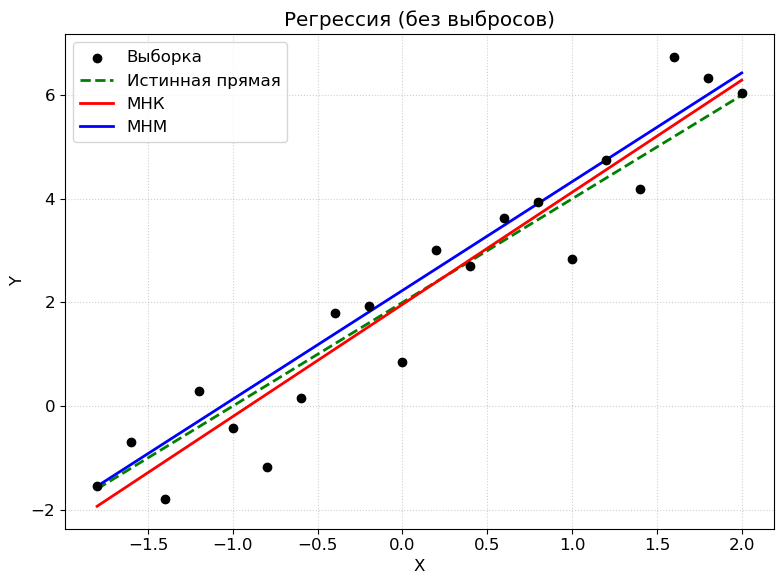

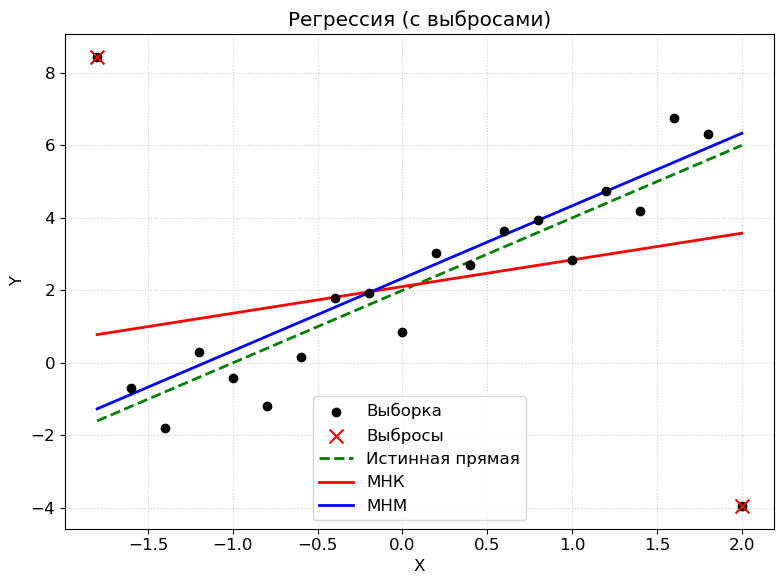

In [35]:
x, y_clean = generate_data()
y_outliers = add_outliers(y_clean)

a_mnk_clean, b_mnk_clean = mnk_fit(x, y_clean)
a_mnm_clean, b_mnm_clean = mnm_fit(x, y_clean)

a_mnk_out, b_mnk_out = mnk_fit(x, y_outliers)
a_mnm_out, b_mnm_out = mnm_fit(x, y_outliers)

print_table("ВЫБОРКА БЕЗ ВЫБРОСОВ", a_mnk_clean, b_mnk_clean, a_mnm_clean, b_mnm_clean)
print_table("ВЫБОРКА С ВЫБРОСАМИ", a_mnk_out, b_mnk_out, a_mnm_out, b_mnm_out)

plot_regression(x, y_clean, a_mnk_clean, b_mnk_clean, a_mnm_clean, b_mnm_clean, 
                title="Регрессия (без выбросов)", show_outliers=False)
plot_regression(x, y_outliers, a_mnk_out, b_mnk_out, a_mnm_out, b_mnm_out, 
                title="Регрессия (с выбросами)", show_outliers=True)